In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# 1. GENERATE SYNTHETIC JET ENGINE SENSOR DATA

def generate_jet_engine_data(n_engines=100, n_cycles=200):
    """
    Generate synthetic jet engine sensor data with degradation patterns
    Sensors: Temperature, Pressure, Vibration, RPM, Fuel Flow
    """
    data = []

    for engine_id in range(n_engines):
        # Random failure cycle for this engine
        failure_cycle = np.random.randint(150, n_cycles)

        # Sensor health degradation rates (random for each engine)
        temp_degrade = np.random.uniform(0.001, 0.003)
        pressure_degrade = np.random.uniform(0.001, 0.0025)
        vibration_degrade = np.random.uniform(0.002, 0.004)
        rpm_degrade = np.random.uniform(0.0005, 0.002)
        fuel_degrade = np.random.uniform(0.001, 0.003)

        for cycle in range(n_cycles):
            # Normal operation values
            temperature = 550 + np.random.normal(0, 5)
            pressure = 14.7 + np.random.normal(0, 0.3)
            vibration = 0.5 + np.random.normal(0, 0.05)
            rpm = 5000 + np.random.normal(0, 50)
            fuel_flow = 100 + np.random.normal(0, 2)

            # Add degradation as we approach failure
            if cycle > failure_cycle * 0.7:
                degradation_factor = (cycle - failure_cycle * 0.7) / (failure_cycle * 0.3)
                temperature += degradation_factor * 50 * temp_degrade * 100
                pressure -= degradation_factor * 2 * pressure_degrade * 100
                vibration += degradation_factor * 2 * vibration_degrade * 100
                rpm -= degradation_factor * 200 * rpm_degrade * 100
                fuel_flow += degradation_factor * 20 * fuel_degrade * 100

            # Calculate sensor health (100% at start, degrades over time)
            temp_health = max(0, 100 - cycle * temp_degrade * 100)
            pressure_health = max(0, 100 - cycle * pressure_degrade * 100)
            vibration_health = max(0, 100 - cycle * vibration_degrade * 100)
            rpm_health = max(0, 100 - cycle * rpm_degrade * 100)
            fuel_health = max(0, 100 - cycle * fuel_degrade * 100)

            # Overall health is average of all sensors
            overall_health = np.mean([temp_health, pressure_health, vibration_health,
                                     rpm_health, fuel_health])

            # RUL (Remaining Useful Life)
            rul = max(0, failure_cycle - cycle)

            data.append({
                'engine_id': engine_id,
                'cycle': cycle,
                'temperature': temperature,
                'pressure': pressure,
                'vibration': vibration,
                'rpm': rpm,
                'fuel_flow': fuel_flow,
                'temp_health': temp_health,
                'pressure_health': pressure_health,
                'vibration_health': vibration_health,
                'rpm_health': rpm_health,
                'fuel_health': fuel_health,
                'overall_health': overall_health,
                'rul': rul,
                'failure_cycle': failure_cycle
            })

    return pd.DataFrame(data)

# Generate data
print("\n" + "="*70)
print("GENERATING SYNTHETIC JET ENGINE DATA")
print("="*70)
df = generate_jet_engine_data(n_engines=100, n_cycles=200)
print(f"\nGenerated {len(df)} data points from {df['engine_id'].nunique()} engines")
print(f"\nData shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())



GENERATING SYNTHETIC JET ENGINE DATA

Generated 20000 data points from 100 engines

Data shape: (20000, 15)

First few rows:
   engine_id  cycle  temperature   pressure  vibration          rpm  \
0          0      0   549.526895  14.421352   0.455738  4979.390576   
1          0      1   550.820824  14.769929   0.505900  5073.118906   
2          0      2   537.804471  14.881032   0.487448  4991.806644   
3          0      3   557.434905  14.692663   0.517778  5020.850555   
4          0      4   548.533004  14.691048   0.504756  5033.232717   

    fuel_flow  temp_health  pressure_health  vibration_health  rpm_health  \
0   99.034762   100.000000       100.000000        100.000000  100.000000   
1  103.077430    99.740691        99.872485         99.644062   99.860472   
2   97.047341    99.481383        99.744970         99.288124   99.720945   
3  101.664924    99.222074        99.617454         98.932185   99.581417   
4   99.719563    98.962766        99.489939         98.576247 

In [4]:
# 2. DATA PREPROCESSING


print("\n" + "="*70)
print("DATA PREPROCESSING")
print("="*70)

# Sensor features
sensor_features = ['temperature', 'pressure', 'vibration', 'rpm', 'fuel_flow', 'cycle']
health_targets = ['temp_health', 'pressure_health', 'vibration_health',
                  'rpm_health', 'fuel_health', 'overall_health']

# Normalize features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X = df[sensor_features].values
y = df[health_targets].values

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


DATA PREPROCESSING
Training samples: 16000
Testing samples: 4000


In [5]:
# 3. PHYSICS-INFORMED NEURAL NETWORK MODEL

print("\n" + "="*70)
print("BUILDING PHYSICS-INFORMED NEURAL NETWORK")
print("="*70)

def build_pinn_model(input_dim, output_dim):
    """
    Build PINN with physics constraints for sensor health prediction
    """
    inputs = layers.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(64, activation='relu')(x)

    # Output layer for sensor health (0-1 range after sigmoid)
    outputs = layers.Dense(output_dim, activation='sigmoid')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# Build model
model = build_pinn_model(len(sensor_features), len(health_targets))

# Custom loss with physics constraints
def physics_informed_loss(y_true, y_pred):
    """
    Loss function with physics constraints:
    1. Health should decrease monotonically with cycles
    2. Health should be between 0 and 100%
    3. Sensor readings should correlate with health
    """
    # MSE loss
    mse_loss = tf.reduce_mean(tf.square(y_true - y_pred))

    # Physics constraint: health should be positive
    health_constraint = tf.reduce_mean(tf.maximum(0.0, -y_pred))

    # Physics constraint: health should not exceed 100%
    upper_constraint = tf.reduce_mean(tf.maximum(0.0, y_pred - 1.0))

    # Total loss
    total_loss = mse_loss + 0.1 * health_constraint + 0.1 * upper_constraint

    return total_loss

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=physics_informed_loss,
    metrics=['mae', 'mse']
)

print("\nModel Architecture:")
model.summary()



BUILDING PHYSICS-INFORMED NEURAL NETWORK

Model Architecture:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,510 (302.77 KB)

 Trainable params: 76,486 (298.77 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [6]:
# 4. TRAIN THE MODEL

print("\n" + "="*70)
print("TRAINING PHYSICS-INFORMED NEURAL NETWORK")
print("="*70)

# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6
)

# Train
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)



TRAINING PHYSICS-INFORMED NEURAL NETWORK
Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0259 - mae: 0.1169 - mse: 0.0259 - val_loss: 0.0195 - val_mae: 0.1091 - val_mse: 0.0195 - learning_rate: 0.0010
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0120 - mae: 0.0833 - mse: 0.0120 - val_loss: 0.0107 - val_mae: 0.0794 - val_mse: 0.0107 - learning_rate: 0.0010
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0113 - mae: 0.0804 - mse: 0.0113 - val_loss: 0.0104 - val_mae: 0.0783 - val_mse: 0.0104 - learning_rate: 0.0010
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0108 - mae: 0.0783 - mse: 0.0108 - val_loss: 0.0107 - val_mae: 0.0792 - val_mse: 0.0107 - learning_rate: 0.0010
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0106 - mae: 0.0773 - mse: 0.0106 - val_loss: 0.0101 - val_mae: 0.0769 - val_mse: 0.0101 - learning_rate: 0.0010
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0104 - mae: 0.0765 -

In [7]:
# 5. EVALUATE MODEL

print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

# Predictions
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

# Calculate metrics for each sensor
print("\nSensor Health Prediction Accuracy:")
print("-" * 70)
for i, sensor in enumerate(health_targets):
    mae = np.mean(np.abs(y_test_original[:, i] - y_pred[:, i]))
    rmse = np.sqrt(np.mean((y_test_original[:, i] - y_pred[:, i])**2))
    print(f"{sensor:20s} - MAE: {mae:.2f}%, RMSE: {rmse:.2f}%")



MODEL EVALUATION
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Sensor Health Prediction Accuracy:
----------------------------------------------------------------------
temp_health          - MAE: 4.16%, RMSE: 5.69%
pressure_health      - MAE: 3.76%, RMSE: 5.00%
vibration_health     - MAE: 3.93%, RMSE: 5.21%
rpm_health           - MAE: 3.82%, RMSE: 5.06%
fuel_health          - MAE: 4.53%, RMSE: 6.10%
overall_health       - MAE: 1.83%, RMSE: 2.52%


In [8]:
# 6. PREDICT FAILING SENSORS

def predict_sensor_failure(model, X, scaler_X, scaler_y, threshold=70):
    """
    Predict which sensors are likely to fail based on health threshold
    """
    X_scaled = scaler_X.transform(X)
    predictions_scaled = model.predict(X_scaled, verbose=0)
    predictions = scaler_y.inverse_transform(predictions_scaled)

    results = []
    sensor_names = ['Temperature', 'Pressure', 'Vibration', 'RPM', 'Fuel Flow']

    for i in range(len(predictions)):
        sensor_healths = predictions[i][:5]  # First 5 are individual sensors
        overall_health = predictions[i][5]

        failing_sensors = []
        for j, (sensor, health) in enumerate(zip(sensor_names, sensor_healths)):
            if health < threshold:
                failing_sensors.append({
                    'sensor': sensor,
                    'health': health,
                    'status': 'CRITICAL' if health < 50 else 'WARNING'
                })

        results.append({
            'sample_id': i,
            'overall_health': overall_health,
            'sensor_healths': dict(zip(sensor_names, sensor_healths)),
            'failing_sensors': failing_sensors
        })

    return results

# Test on a few samples
print("\n" + "="*70)
print("SENSOR FAILURE PREDICTION")
print("="*70)

test_samples = X_test[:5]
X_test_original = scaler_X.inverse_transform(test_samples)
failure_predictions = predict_sensor_failure(model, X_test_original, scaler_X, scaler_y)

for pred in failure_predictions:
    print(f"\n{'='*70}")
    print(f"Sample {pred['sample_id']} - Overall Engine Health: {pred['overall_health']:.1f}%")
    print(f"{'-'*70}")
    print("Individual Sensor Health:")
    for sensor, health in pred['sensor_healths'].items():
        status = "✓ HEALTHY" if health >= 70 else ("⚠ WARNING" if health >= 50 else "✗ CRITICAL")
        print(f"  {sensor:15s}: {health:5.1f}% {status}")

    if pred['failing_sensors']:
        print(f"\n⚠️  FAILING SENSORS DETECTED:")
        for fs in pred['failing_sensors']:
            print(f"  - {fs['sensor']:15s}: {fs['health']:5.1f}% [{fs['status']}]")
    else:
        print(f"\n✓ All sensors operating normally")


SENSOR FAILURE PREDICTION

Sample 0 - Overall Engine Health: 89.8%
----------------------------------------------------------------------
Individual Sensor Health:
  Temperature    :  89.5% ✓ HEALTHY
  Pressure       :  91.1% ✓ HEALTHY
  Vibration      :  84.3% ✓ HEALTHY
  RPM            :  93.8% ✓ HEALTHY
  Fuel Flow      :  90.2% ✓ HEALTHY

✓ All sensors operating normally

Sample 1 - Overall Engine Health: 91.5%
----------------------------------------------------------------------
Individual Sensor Health:
  Temperature    :  91.4% ✓ HEALTHY
  Pressure       :  92.5% ✓ HEALTHY
  Vibration      :  86.6% ✓ HEALTHY
  RPM            :  94.7% ✓ HEALTHY
  Fuel Flow      :  91.6% ✓ HEALTHY

✓ All sensors operating normally

Sample 2 - Overall Engine Health: 86.6%
----------------------------------------------------------------------
Individual Sensor Health:
  Temperature    :  86.6% ✓ HEALTHY
  Pressure       :  88.5% ✓ HEALTHY
  Vibration      :  79.2% ✓ HEALTHY
  RPM            :  91.


GENERATING VISUALIZATIONS


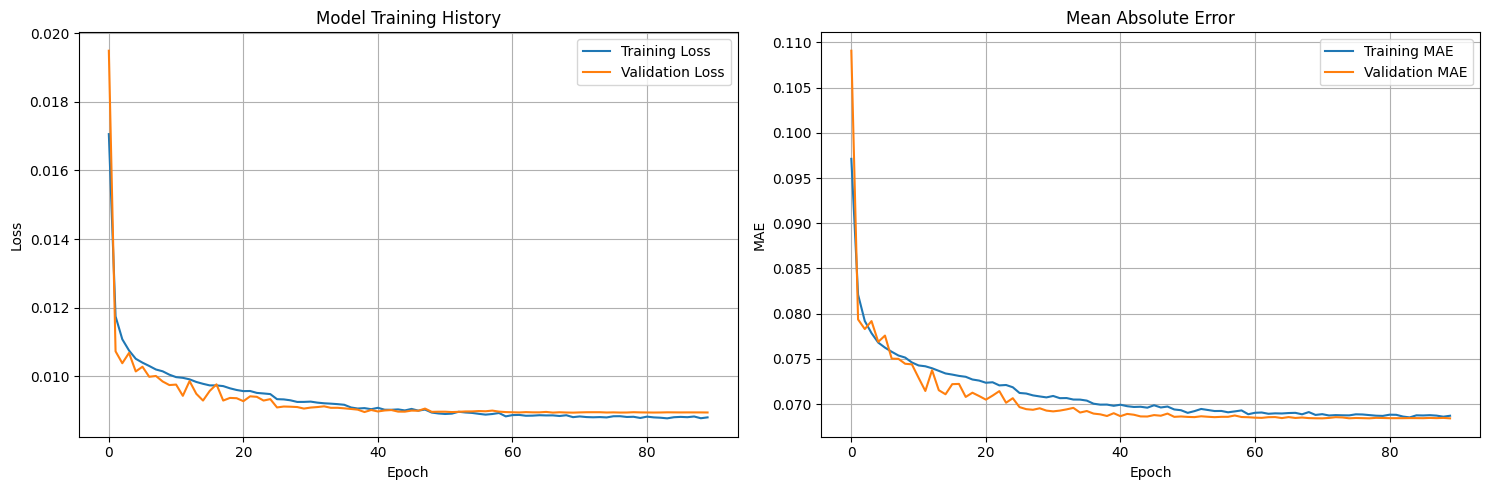

Saved: training_history.png


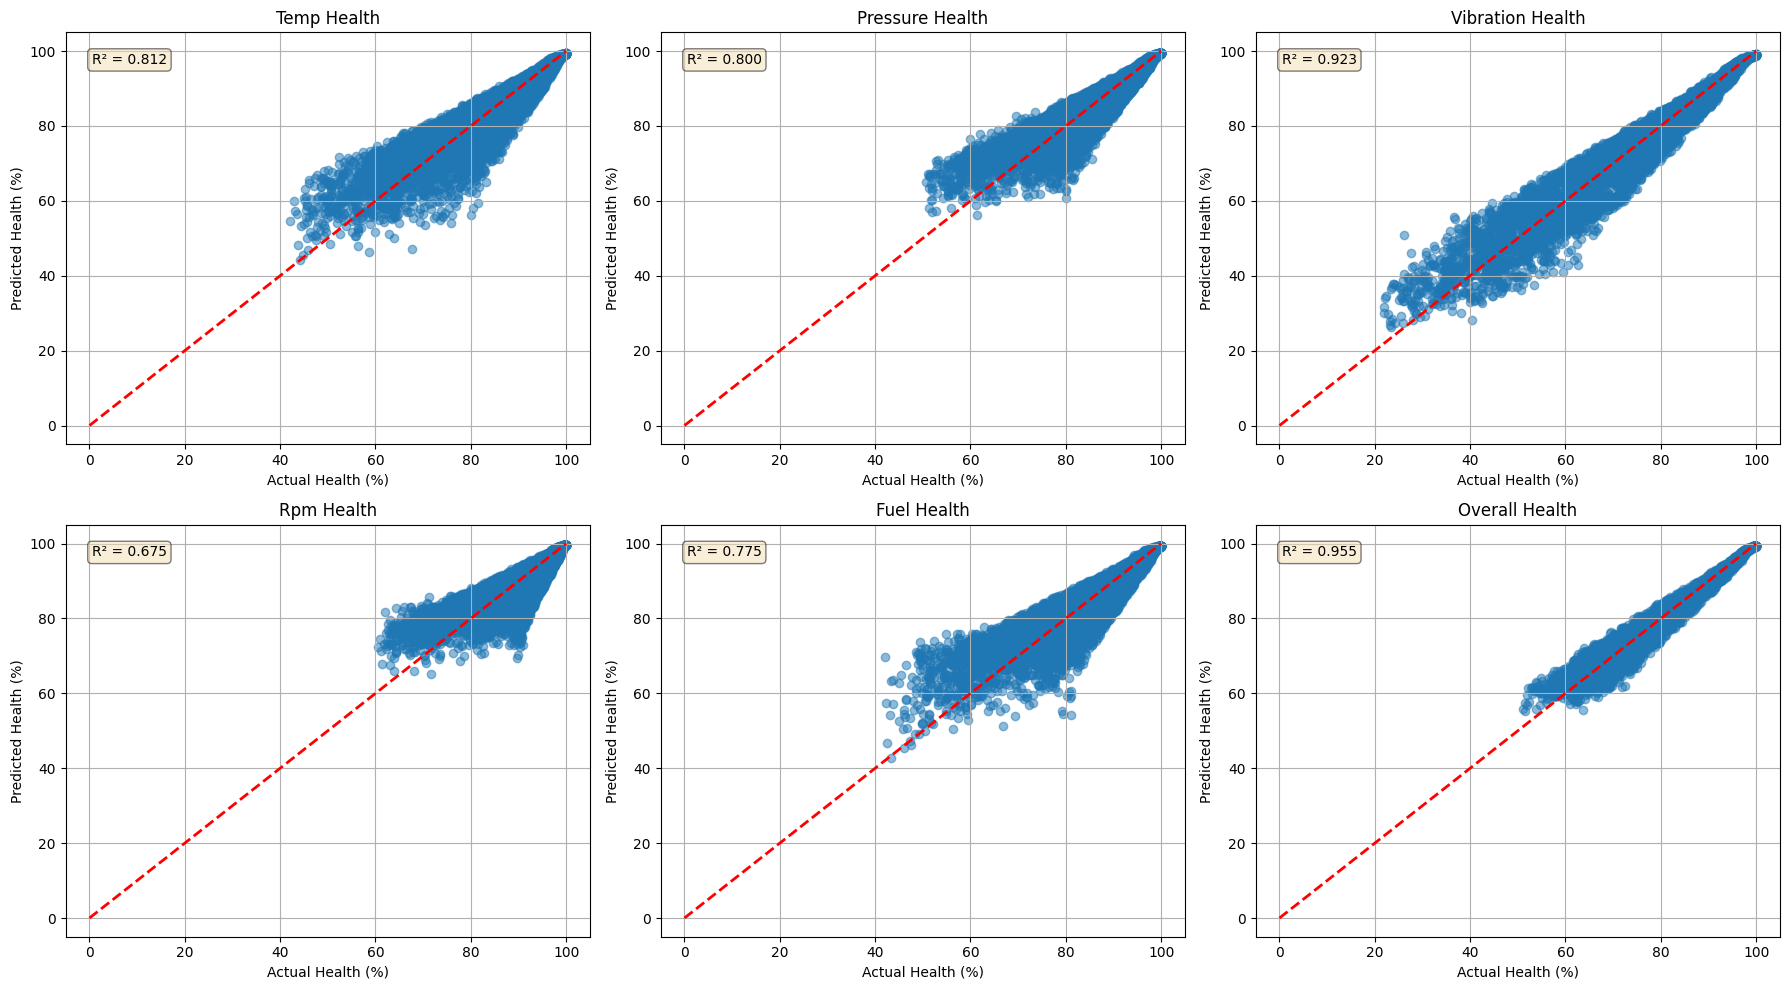

Saved: prediction_accuracy.png


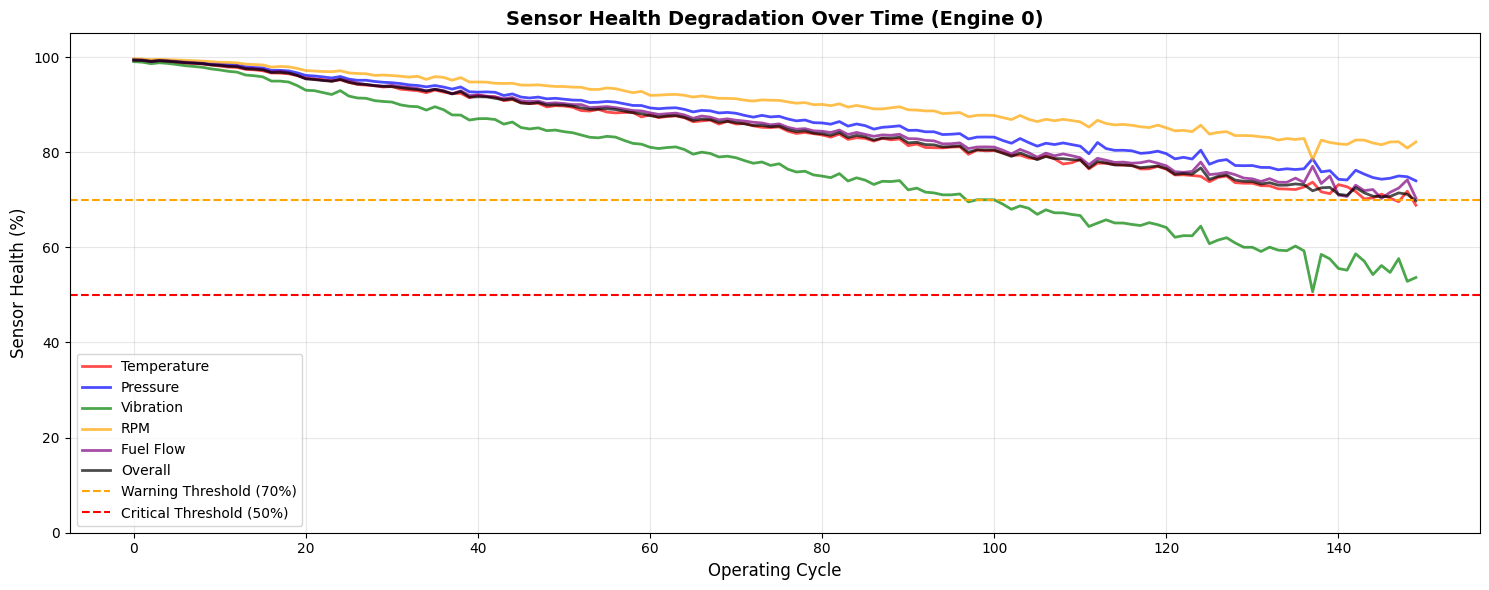

Saved: sensor_health_timeline.png


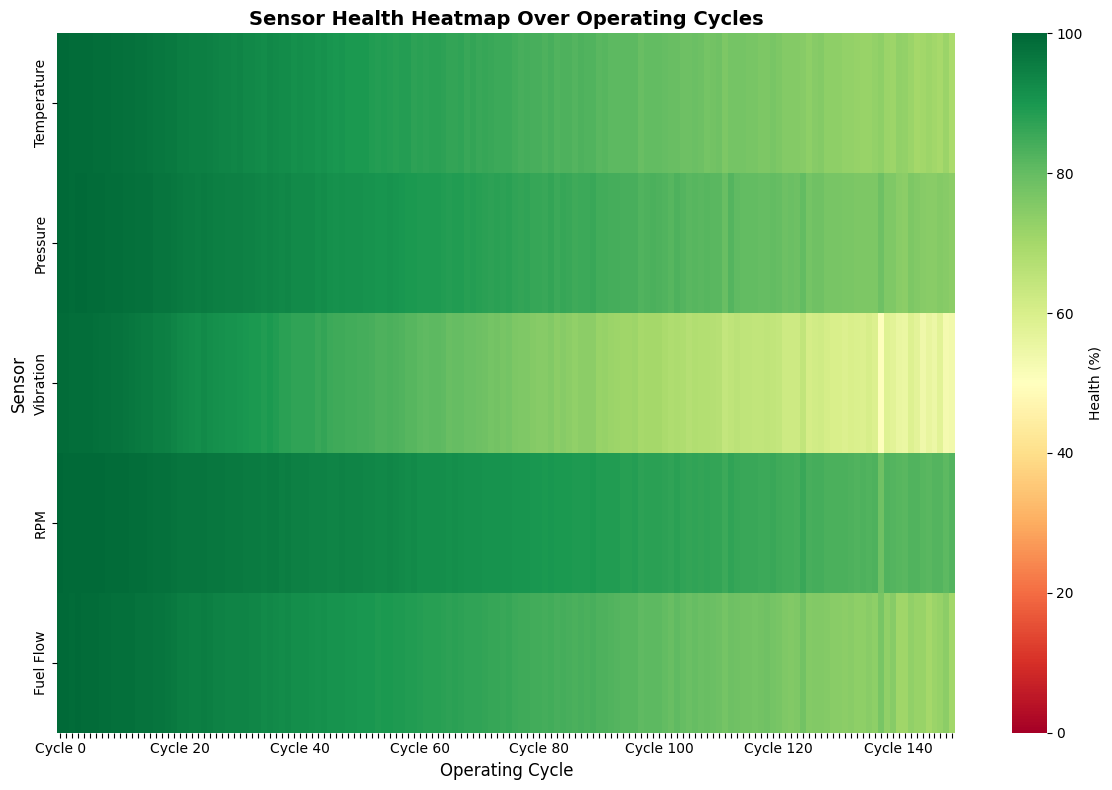

Saved: sensor_health_heatmap.png


In [9]:
# ============================================================================
# 7. VISUALIZATIONS
# ============================================================================

print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

# Plot 1: Training History
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model Training History')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: training_history.png")

# Plot 2: Prediction vs Actual for all sensors
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sensor in enumerate(health_targets):
    axes[i].scatter(y_test_original[:, i], y_pred[:, i], alpha=0.5)
    axes[i].plot([0, 100], [0, 100], 'r--', lw=2)
    axes[i].set_xlabel('Actual Health (%)')
    axes[i].set_ylabel('Predicted Health (%)')
    axes[i].set_title(f'{sensor.replace("_", " ").title()}')
    axes[i].grid(True)

    # Add R² score
    from sklearn.metrics import r2_score
    r2 = r2_score(y_test_original[:, i], y_pred[:, i])
    axes[i].text(0.05, 0.95, f'R² = {r2:.3f}',
                transform=axes[i].transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('prediction_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: prediction_accuracy.png")

# Plot 3: Sensor Health Over Time for one engine
engine_data = df[df['engine_id'] == 0].head(150)
X_engine = engine_data[sensor_features].values
X_engine_scaled = scaler_X.transform(X_engine)
health_pred_scaled = model.predict(X_engine_scaled, verbose=0)
health_pred = scaler_y.inverse_transform(health_pred_scaled)

fig, ax = plt.subplots(figsize=(15, 6))
sensor_names = ['Temperature', 'Pressure', 'Vibration', 'RPM', 'Fuel Flow', 'Overall']
colors = ['red', 'blue', 'green', 'orange', 'purple', 'black']

for i, (name, color) in enumerate(zip(sensor_names, colors)):
    ax.plot(engine_data['cycle'], health_pred[:, i],
           label=name, linewidth=2, color=color, alpha=0.7)

ax.axhline(y=70, color='orange', linestyle='--', label='Warning Threshold (70%)')
ax.axhline(y=50, color='red', linestyle='--', label='Critical Threshold (50%)')
ax.set_xlabel('Operating Cycle', fontsize=12)
ax.set_ylabel('Sensor Health (%)', fontsize=12)
ax.set_title('Sensor Health Degradation Over Time (Engine 0)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 105])

plt.tight_layout()
plt.savefig('sensor_health_timeline.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: sensor_health_timeline.png")

# Plot 4: Heatmap of Sensor Health
fig, ax = plt.subplots(figsize=(12, 8))
health_matrix = health_pred[:, :5].T  # Only individual sensors
sns.heatmap(health_matrix, cmap='RdYlGn', vmin=0, vmax=100,
           xticklabels=[f'Cycle {i}' if i % 20 == 0 else '' for i in engine_data['cycle']],
           yticklabels=['Temperature', 'Pressure', 'Vibration', 'RPM', 'Fuel Flow'],
           cbar_kws={'label': 'Health (%)'},
           ax=ax)
ax.set_title('Sensor Health Heatmap Over Operating Cycles', fontsize=14, fontweight='bold')
ax.set_xlabel('Operating Cycle', fontsize=12)
ax.set_ylabel('Sensor', fontsize=12)

plt.tight_layout()
plt.savefig('sensor_health_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: sensor_health_heatmap.png")


In [10]:
# ============================================================================
# 8. SAVE MODEL
# ============================================================================

print("\n" + "="*70)
print("SAVING MODEL AND SCALERS")
print("="*70)

model.save('jet_engine_pinn_model.h5')
print("✓ Model saved: jet_engine_pinn_model.h5")

# Save scalers
import pickle
with open('scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)
with open('scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)
print("✓ Scalers saved: scaler_X.pkl, scaler_y.pkl")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print("\nGenerated Files:")
print("  1. jet_engine_pinn_model.h5 - Trained PINN model")
print("  2. scaler_X.pkl - Input feature scaler")
print("  3. scaler_y.pkl - Output health scaler")
print("  4. training_history.png - Training metrics")
print("  5. prediction_accuracy.png - Prediction accuracy plots")
print("  6. sensor_health_timeline.png - Health over time")
print("  7. sensor_health_heatmap.png - Health heatmap")
print("\nYou can now use this model to predict sensor health and identify failing sensors!")


SAVING MODEL AND SCALERS
✓ Model saved: jet_engine_pinn_model.h5
✓ Scalers saved: scaler_X.pkl, scaler_y.pkl

ANALYSIS COMPLETE!

Generated Files:
  1. jet_engine_pinn_model.h5 - Trained PINN model
  2. scaler_X.pkl - Input feature scaler
  3. scaler_y.pkl - Output health scaler
  4. training_history.png - Training metrics
  5. prediction_accuracy.png - Prediction accuracy plots
  6. sensor_health_timeline.png - Health over time
  7. sensor_health_heatmap.png - Health heatmap

You can now use this model to predict sensor health and identify failing sensors!


In [11]:
# 9. LOAD MODEL & USER INPUT PREDICTION

print("\n" + "="*70)
print("USER INPUT: SENSOR HEALTH PREDICTION")
print("="*70)

import tensorflow as tf
from tensorflow import keras
import pickle
import numpy as np

# LOAD MODEL & SCALERS

model = keras.models.load_model(
    'jet_engine_pinn_model.h5',
    custom_objects={'physics_informed_loss': physics_informed_loss}
)

with open('scaler_X.pkl', 'rb') as f:
    scaler_X = pickle.load(f)

with open('scaler_y.pkl', 'rb') as f:
    scaler_y = pickle.load(f)

print("✓ Model & Scalers Loaded Successfully")


# USER INPUT SECTION
print("\nEnter the latest sensor readings for prediction:\n")

temperature = float(input("Temperature (°C): "))
pressure = float(input("Pressure (psi): "))
vibration = float(input("Vibration (mm/s): "))
rpm = float(input("RPM: "))
fuel_flow = float(input("Fuel Flow (kg/s): "))
cycle = float(input("Current Operating Cycle: "))

user_input = np.array([[temperature, pressure, vibration, rpm, fuel_flow, cycle]])

# Scale input
user_scaled = scaler_X.transform(user_input)

# Predict
pred_scaled = model.predict(user_scaled)
pred = scaler_y.inverse_transform(pred_scaled)[0]

sensor_names = ["Temperature", "Pressure", "Vibration", "RPM", "Fuel Flow", "Overall Health"]

print("\n" + "="*70)
print(" PREDICTED SENSOR HEALTH")
print("="*70)

for i, name in enumerate(sensor_names):
    health = pred[i]

    if health >= 70:
        status = "✓ HEALTHY"
    elif health >= 50:
        status = "⚠ WARNING"
    else:
        status = "✗ CRITICAL"

    print(f"{name:15s}: {health:6.2f}%   {status}")

print("\nPrediction Complete!")
print("="*70)



USER INPUT: SENSOR HEALTH PREDICTION
✓ Model & Scalers Loaded Successfully

Enter the latest sensor readings for prediction:

Temperature (°C): 553
Pressure (psi): 13.9
Vibration (mm/s): 0.78
RPM: 4800
Fuel Flow (kg/s): 110
Current Operating Cycle: 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step

🔍 PREDICTED SENSOR HEALTH
Temperature    :  88.63%   ✓ HEALTHY
Pressure       :  91.00%   ✓ HEALTHY
Vibration      :  82.70%   ✓ HEALTHY
RPM            :  91.89%   ✓ HEALTHY
Fuel Flow      :  90.42%   ✓ HEALTHY
Overall Health :  88.43%   ✓ HEALTHY

Prediction Complete!
